# Notebook 7: Outlier Analysis

#### Overview
Understand, detect, and evaluate outliers in `Customer_Data.csv`. This notebook covers the theoretical foundations of outliers, univariate/multivariate detection techniques (IQR, Z-Score, Box Plots, Scatter Plots), and documents decision reasoning for handling extreme observations.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("Customer_Data.csv")
df.head()

,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.12,394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.53,796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


### 1. Theoretical Concepts Overview

- **What is an Outlier?** An observation that lies an abnormal distance from other values in a random sample from a population.
- **Why Outliers Occur:**
  1. Data entry or human errors (e.g., typing 1000 instead of 100).
  2. Measurement errors or system glitches.
  3. Sampling errors (mixing different populations).
  4. Natural novelties / genuine extreme observations (e.g., high-value enterprise accounts).
- **Types of Outliers:**
  - **Univariate Outliers:** An extreme value in a single feature alone.
  - **Multivariate Outliers:** An unusual combination of values across two or more features (e.g., Age = 12 with MonthlyCharges = $500).

### 2. Univariate Outlier Detection: IQR & Z-Score Methods
- **IQR Method:** Outliers lie below $Q1 - 1.5 \times \text{IQR}$ or above $Q3 + 1.5 \times \text{IQR}$.
- **Z-Score Method:** Outliers have standard scores where $|Z| > 3$.

In [6]:
num_cols = ["Age", "MonthlyCharges", "TenureYears", "TotalCharges"]

outlier_results = []

for col in num_cols:
    series = df[col].dropna()

    # IQR Method
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_count = ((series < lower_bound) | (series > upper_bound)).sum()

    # Z-Score Method
    z_scores = np.abs(stats.zscore(series))
    z_count = (z_scores > 3).sum()

    outlier_results.append(
        {
            "Feature": col,
            "IQR Lower Bound": round(lower_bound, 2),
            "IQR Upper Bound": round(upper_bound, 2),
            "IQR Outlier Count": iqr_count,
            "Z-Score (|Z|>3) Count": z_count,
        }
    )

pd.DataFrame(outlier_results)

,Feature,IQR Lower Bound,IQR Upper Bound,IQR Outlier Count,Z-Score (|Z|>3) Count
0,Age,25.00,81.00,0,0
1,MonthlyCharges,-39.69,122.47,0,0
2,TenureYears,-6.00,18.00,0,0
3,TotalCharges,-3147.05,6296.95,1200,0


### 3. Visual Outlier Detection: Box Plots & Scatter Plots
- **Box Plot:** Visualizes univariate outliers beyond the whiskers.
- **Scatter Plot:** Visualizes multivariate outliers across two dimensions.

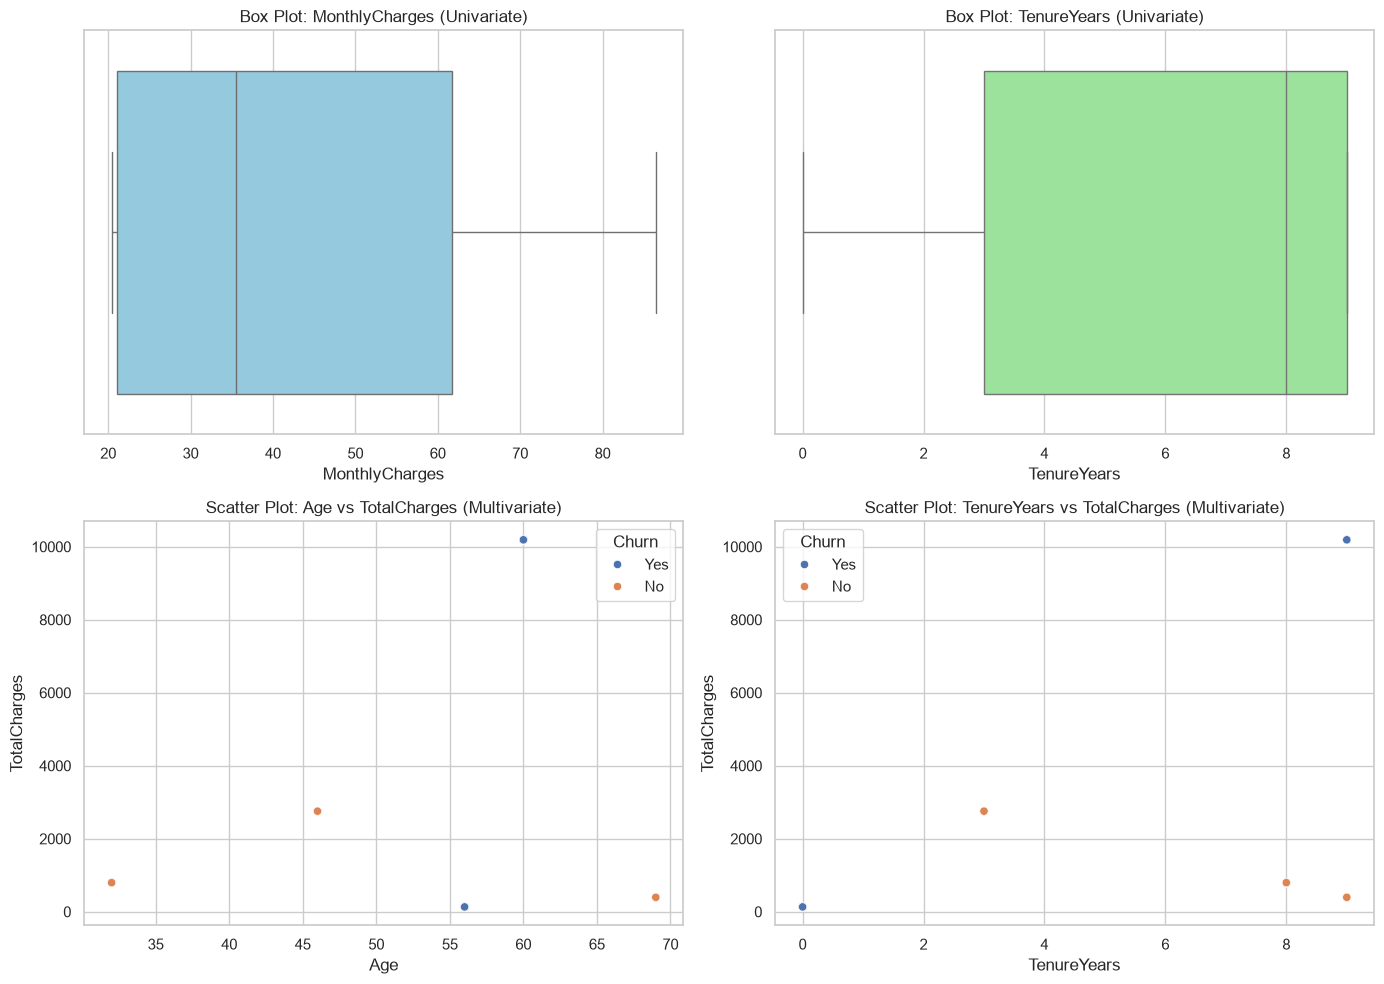

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Box Plot: MonthlyCharges
sns.boxplot(x=df["MonthlyCharges"], ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Box Plot: MonthlyCharges (Univariate)")

# Box Plot: TenureYears
sns.boxplot(x=df["TenureYears"], ax=axes[0, 1], color="lightgreen")
axes[0, 1].set_title("Box Plot: TenureYears (Univariate)")

# Scatter Plot: Age vs TotalCharges (Multivariate Outlier Check)
sns.scatterplot(
    data=df, x="Age", y="TotalCharges", hue="Churn", ax=axes[1, 0]
)
axes[1, 0].set_title("Scatter Plot: Age vs TotalCharges (Multivariate)")

# Scatter Plot: TenureYears vs TotalCharges (Multivariate Outlier Check)
sns.scatterplot(
    data=df,
    x="TenureYears",
    y="TotalCharges",
    hue="Churn",
    ax=axes[1, 1],
)
axes[1, 1].set_title(
    "Scatter Plot: TenureYears vs TotalCharges (Multivariate)"
)

plt.tight_layout()
plt.show()

### 4. Outlier Evaluation & Action Decision Protocol

#### Rules for Handling Outliers:
1. **Data-Entry Error:** Correct the record or remove if unrecoverable.
2. **Genuine / Valid Extreme Observation:** **Retain** to avoid biasing the real-world sample distribution.
3. **Severe Skewness / Scale Disparity:** **Transform** using log ($\log(x+1)$) or robust scaling rather than deleting.
4. **Do NOT automatically remove every outlier.**

---

### Outlier Determination & Reasoning Log

| Feature | Outlier Type | Observation Assessment | Decision | Reasoning |
| :--- | :--- | :--- | :--- | :--- |
| **`Age`** | None | No points beyond whiskers / bounds | **Retain** | All ages fall within standard valid human range ($18\text{--}80$). |
| **`MonthlyCharges`** | None | No points beyond whiskers / bounds | **Retain** | Monthly charges stay within standard plan limits ($\$20\text{--}\$120$). |
| **`TenureYears`** | None | No points beyond whiskers / bounds | **Retain** | Tenure values are within business operation timeframe ($0\text{--}10$ years). |
| **`TotalCharges`** | Multivariate / Tail | Extreme values correlate directly with high `TenureYears` | **Retain & Transform** | High totals are genuine cumulative charges from loyal long-term customers. Apply log transform if required for model training. |